# TP1 — ¿Qué es un mercado en este problema?

**Mentorería DiploDatos 2026** · Proyecto Final: Detección de Ofertas Hoteleras ID90Travel

**Fecha de entrega:** 31/07

---

## Objetivo

Antes de intentar detectar si un precio es una oferta, hay que resolver una pregunta más básica: **¿contra qué se compara ese precio?**

La respuesta no es obvia. No alcanza con decir "contra otros precios del mismo destino" — porque los precios en Las Vegas un viernes de diciembre no tienen nada que ver con los de un martes de febrero, ni los de un hotel económico con los de uno de lujo.

El TP1 es una **exploración abierta del dataset** para entender qué dimensiones producen grupos de observaciones donde los precios se comportan de forma homogénea — es decir, donde comparar tiene sentido.

## Preguntas de investigación

### 1. Definición de mercado: ¿contra qué se compara?

**El problema de la referencia**: para saber si un precio es una oferta necesitás un precio de referencia del mismo mercado. Un hotel en Las Vegas no compite con uno en Orlando — aunque ambos sean destinos turísticos norteamericanos. Pero, ¿Las Vegas y Henderson (ciudad a 30 km) son el mismo mercado? ¿Y Las Vegas y Miami?

**La pregunta de fondo es: ¿qué define que dos destinos pertenecen al mismo mercado hotelero?**

**El problema de la fragmentación**: el dataset contiene ~26.000 nombres de ciudades distintos, con distribución de observaciones muy desigual. El trabajo en turismo hace que se consoliden datos de múltiples proveedores con sus propias estandarizaciones. Esto lleva a tener registros que refieren a la misma ciudad bajo nombres distintos.

**El rol fundamental de `destination_with_nearest.csv`**: este archivo mapea cada ciudad a un `nearest_destination_id` — el ID de un destino canónico cercano que tenga masa suficiente de observaciones. Sin esta consolidación, el análisis carece de la masa estadística necesaria para que cualquier comparación de precios sea confiable.

**Por qué es una hipótesis y no una verdad**: el criterio de agrupación usado es proximidad geográfica — razonable, pero discutible. ¿Miami y Miami Beach comparten realmente la misma dinámica de precios, o tienen perfiles distintos que al mezclarlos se distorsionan mutuamente?

**El mercado va más allá de la geografía**: la temporada del año, el día de la semana, la categoría del hotel o la duración de la estadía pueden ser tan determinantes como la geografía — o más.

### 2. Definición de contexto: ¿qué condiciones hacen que dos precios sean comparables?

El precio de un hotel nunca se evalúa en el vacío. Una habitación a $80/noche en Miami puede ser una ganga en diciembre (temporada alta) y un precio elevado en febrero (temporada baja).

**¿Qué conjunto de variables define que dos búsquedas son suficientemente similares como para comparar sus precios?**

Dimensiones a considerar:
- **Temporal**: mes del año, semana del mes, día de la semana, días especiales o eventos
- **Composición del viaje**: noches de estadía, número de habitaciones, adultos, niños
- **Categoría del alojamiento**: ¿los hoteles más caros de un destino siguen sus propias dinámicas?
- **Condiciones del mercado**: ¿el número de hoteles disponibles (`avg_hotel_count`) afecta los precios observados?

*La definición de CONTEXTO determina directamente la calidad de cualquier algoritmo de detección.*

## Dimensiones candidatas a explorar

No es necesario explorar todas — lo importante es llegar a una **hipótesis razonada** sobre qué combinación produce segmentos internamente coherentes y suficientemente densos como para sostener un análisis estadístico.

| Dimensión | Variable(s) | Pregunta guía |
|-----------|-------------|---------------|
| Localización geográfica | `city`, `state`, `country`, `destination_final` | ¿Los precios son comparables entre destinos cercanos? |
| Día de la semana | derivada de `date_start` | ¿Los precios suben los fines de semana? ¿En todos los destinos por igual? |
| Temporada del año | `month` derivado de `date_start` | ¿La estacionalidad afecta igual a todos los mercados? |
| Categoría del hotel | segmentos de precio (`price_bucket`) | ¿Los hoteles económicos siguen el mismo ciclo que los de lujo? |
| Duración de la estadía | `nights` | ¿Las estadías largas tienen dinámica distinta? |
| Demanda | `count_repeated` | ¿Los destinos con alta demanda tienen precios más estables? |
| Oferta | `avg_hotel_count` | ¿Cuando colapsa la oferta, suben los precios de forma distinta? |

## Preguntas disparadoras

Algunas preguntas para guiar la exploración:

1. ¿Los precios suben los fines de semana?
2. ¿En todos los destinos por igual, o solo en los de ocio?
3. ¿Los hoteles económicos siguen el mismo ciclo estacional que los de lujo?
4. ¿Hay destinos donde la oferta disponible (`avg_hotel_count`) colapsa en ciertas fechas y eso afecta los precios de forma distinta al resto?
5. ¿Qué combinación de variables produce grupos con precios más homogéneos (menor varianza interna)?

## Datos disponibles

| Archivo | Descripción |
|---------|-------------|
| `datos_historicos_2024.csv` | ~2.5M registros de búsquedas hoteleras 2024 (~200 MB) |
| `datos_historicos_2025.csv` | ~2.5M registros de búsquedas hoteleras 2025 (~200 MB) |
| `destination_with_nearest.csv` | Mapping de ~26.000 ciudades a destinos canónicos |

**Importante**: cada fila no representa el precio de un hotel individual, sino el rango estadístico de *todos* los hoteles mostrados en esa búsqueda.

### Columnas principales del dataset

| Columna | Descripción |
|---------|-------------|
| `city`, `state`, `country`, `country_code` | Destino geográfico |
| `date_start`, `date_end`, `nights` | Fechas y duración de la estadía |
| `number_of_rooms`, `number_of_adults`, `number_of_kids` | Composición del viaje |
| `count_repeated` | Cantidad de veces que se realizó esta búsqueda (proxy de demanda) |
| `avg_hotel_count` | Promedio de hoteles disponibles mostrados (proxy de oferta) |
| `avg_price_average` | **Variable central**: precio promedio del conjunto de hoteles en USD |
| `max_price_high`, `min_price_low` | Rango de precios del mercado |

### Datos descargados en: `../data/`

## Entrega esperada

Notebook con:

1. **Visualizaciones** que muestren el comportamiento de los precios a lo largo de las distintas dimensiones
2. **Hipótesis documentada** sobre qué segmentación de mercado propone el grupo — y por qué
3. **Análisis de densidad**: ¿las segmentaciones propuestas generan suficientes observaciones por grupo para ser estadísticamente confiables?

---

---
# Exploración inicial · Setup y carga de datos

Las celdas a continuación replican los pasos clave del `exploratory_analysis.ipynb` para que puedas arrancar la exploración del TP1 directamente.

In [182]:
import sys
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))
from auxiliary_functions import (
    load_all_historicals,
    load_destination_mapping,
    standardize_prices,
    expand_dates_dataframe,
    add_temporal_features,
    apply_destination_mapping,
)
import config

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)
print('Librerías importadas correctamente')
print(f'Directorio de datos: {config.DATA_DIR}')

Librerías importadas correctamente
Directorio de datos: /home/francisco/Documents/GITHUB/mentoria/data


### Carga de datos

Se carga una **muestra de 100.000 registros** para exploración rápida. Para el análisis completo, usar `load_all_historicals()`.

In [183]:
archivos = sorted(glob.glob(str(config.DATA_DIR / config.HISTORICALS_FILE_PATTERN)))
if not archivos:
    raise FileNotFoundError(f'No se encontraron archivos en {config.DATA_DIR}')

df_raw = pd.read_csv(archivos[0], nrows=100_000)
print(f'Archivo:             {Path(archivos[0]).name}')
print(f'Registros cargados:  {len(df_raw):>12,}  (muestra de 100k)')
print(f'Columnas:            {len(df_raw.columns)}')
print()
print('Lista de columnas:')
for col in df_raw.columns:
    print(f'  - {col}  ({df_raw[col].dtype})')

Archivo:             datos_historicos_2024.csv
Registros cargados:       100,000  (muestra de 100k)
Columnas:            17

Lista de columnas:
  - city  (str)
  - state  (str)
  - country  (str)
  - country_code  (str)
  - date_start  (str)
  - date_end  (str)
  - number_of_adults  (int64)
  - number_of_rooms  (int64)
  - number_of_kids  (int64)
  - nights  (int64)
  - count_repeated  (int64)
  - avg_hotel_count  (float64)
  - min_hotel_count  (int64)
  - max_hotel_count  (int64)
  - avg_price_average  (float64)
  - max_price_high  (float64)
  - min_price_low  (float64)


In [184]:
df_raw.head(3)

,city,state,country,country_code,date_start,date_end,number_of_adults,number_of_rooms,number_of_kids,nights,count_repeated,avg_hotel_count,min_hotel_count,max_hotel_count,avg_price_average,max_price_high,min_price_low
0,남구,Busan,South Korea,kr,2024-03-26,2024-03-30,5,1,0,4,2,22.00,22,22,124.70,227.10,54.63
1,동구,Busan,South Korea,kr,2024-03-01,2024-03-04,4,2,0,3,1,5.00,5,5,108.69,173.39,52.84
2,동구,Busan,South Korea,kr,2024-03-02,2024-03-04,2,1,0,2,2,5.00,5,5,77.50,126.86,47.04


### Cobertura del dataset

In [185]:
print('COBERTURA DEL DATASET')
print('=' * 45)
print(f"  Fecha inicio:       {df_raw['date_start'].min()}")
print(f"  Fecha fin:          {df_raw['date_start'].max()}")
print(f"  Países:             {df_raw['country'].nunique()}")
print(f"  Estados/Provincias: {df_raw['state'].nunique():,}")
print(f"  Ciudades:           {df_raw['city'].nunique():,}")
print()
print('DEMANDA (count_repeated = búsquedas agregadas)')
print('=' * 45)
print(f"  Total búsquedas:    {df_raw['count_repeated'].sum():,.0f}")
print(f"  Media por registro: {df_raw['count_repeated'].mean():.1f}")
print()
print('PRECIOS (avg_price_average)')
print('=' * 45)
df_raw['avg_price_average'].describe()

COBERTURA DEL DATASET
  Fecha inicio:       2024-01-01
  Fecha fin:          2024-12-30
  Países:             102
  Estados/Provincias: 383
  Ciudades:           1,222

DEMANDA (count_repeated = búsquedas agregadas)
  Total búsquedas:    584,080
  Media por registro: 5.8

PRECIOS (avg_price_average)


count   100000.00
mean       256.64
std        491.66
min          9.38
25%        128.58
50%        175.09
75%        256.52
max      43310.77
Name: avg_price_average, dtype: float64

---
## ¿Qué destinos dominan el dataset?

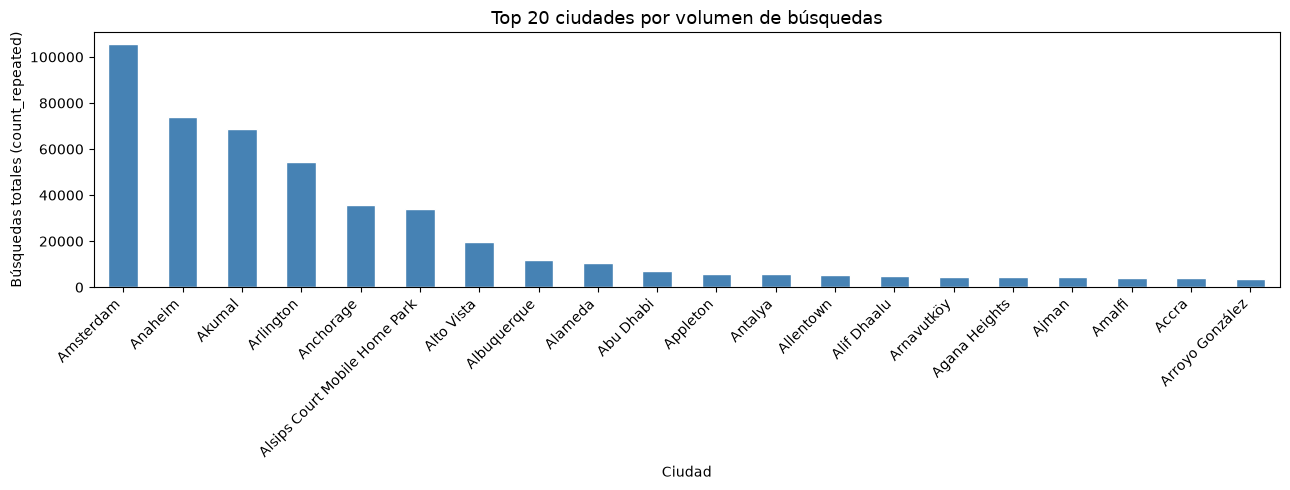

Top 5 ciudades concentran el 57.9% del total de búsquedas.


In [186]:
top_dest = (
    df_raw.groupby('city')['count_repeated']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(13, 5))
top_dest.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 ciudades por volumen de búsquedas', fontsize=13)
ax.set_xlabel('Ciudad')
ax.set_ylabel('Búsquedas totales (count_repeated)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top5_pct = top_dest.head(5).sum() / df_raw['count_repeated'].sum()
print(f'Top 5 ciudades concentran el {top5_pct:.1%} del total de búsquedas.')

---
## Normalización de precios

```
precio_normalizado = precio_total / (noches × habitaciones × (adultos + niños))
```

Esto produce un **precio por persona por habitación por noche**, comparable entre búsquedas de cualquier composición.

In [187]:
df = df_raw.drop_duplicates()
df = standardize_prices(df)

print('Comparación precio total vs. precio normalizado:')
df[['avg_price_average', 'avg_price_average_std']].describe()

2026-08-06 23:12:31,997 - INFO - ✓ Precios estandarizados: 100,000 registros


Comparación precio total vs. precio normalizado:


,avg_price_average,avg_price_average_std
count,100000.00,100000.00
mean,256.64,241.38
std,491.66,475.29
min,9.38,0.10
25%,128.58,119.56
50%,175.09,168.24
75%,256.52,248.49
max,43310.77,43310.77


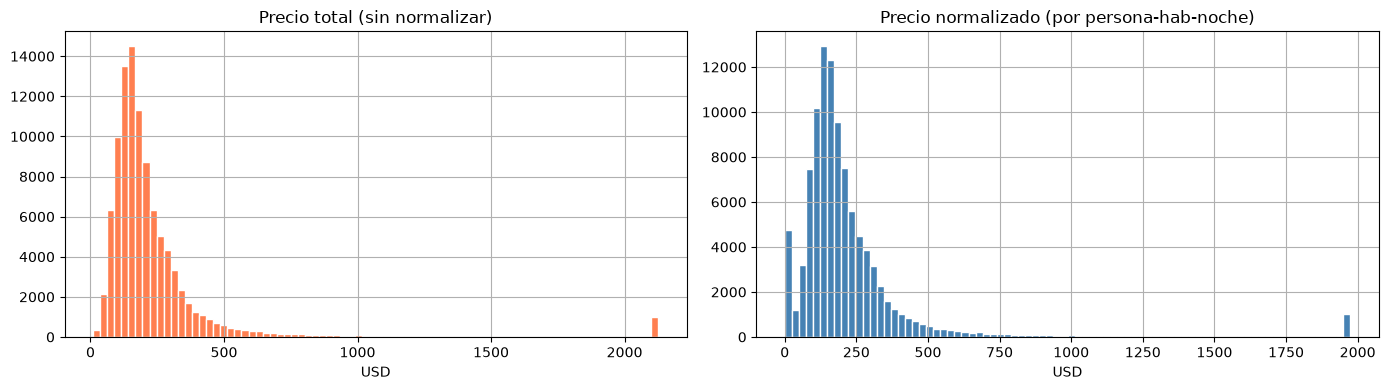

In [188]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

clip_raw = df['avg_price_average'].quantile(0.99)
df['avg_price_average'].clip(upper=clip_raw).hist(
    bins=80, ax=axes[0], color='coral', edgecolor='white'
)
axes[0].set_title('Precio total (sin normalizar)')
axes[0].set_xlabel('USD')

clip_std = df['avg_price_average_std'].quantile(0.99)
df['avg_price_average_std'].clip(upper=clip_std).hist(
    bins=80, ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Precio normalizado (por persona-hab-noche)')
axes[1].set_xlabel('USD')

plt.tight_layout()
plt.show()

---
## Expansión temporal y features

Cada registro representa una estadía multi-noche. Para análisis con resolución semanal, expandimos a observaciones diarias y agregamos `month` y `week_in_month`.

In [189]:
registros_antes = len(df)
df = expand_dates_dataframe(df)
print(f'Registros antes:   {registros_antes:>12,}')
print(f'Registros después: {len(df):>12,}')
print(f'Factor expansión:  {len(df)/registros_antes:.2f}x')

df = add_temporal_features(df)
print(f'\nColumnas agregadas: month, week_in_month')
df[['date_start', 'date_end', 'nights', 'date', 'month', 'week_in_month']].head()

2026-08-06 23:12:32,681 - INFO - Expandiendo 100,000 registros a días (versión optimizada)...
2026-08-06 23:12:33,019 - INFO - ✓ Expansión: 100,000 → 438,858 observaciones diarias
2026-08-06 23:12:33,103 - INFO - Features temporales generadas: month, week_in_month


Registros antes:        100,000
Registros después:      438,858
Factor expansión:  4.39x

Columnas agregadas: month, week_in_month


,date_start,date_end,nights,date,month,week_in_month
0,2024-03-26,2024-03-30,4,2024-03-26,3,4
0,2024-03-26,2024-03-30,4,2024-03-27,3,4
0,2024-03-26,2024-03-30,4,2024-03-28,3,4
0,2024-03-26,2024-03-30,4,2024-03-29,3,4
0,2024-03-26,2024-03-30,4,2024-03-30,3,4


### Estacionalidad: precio promedio por mes

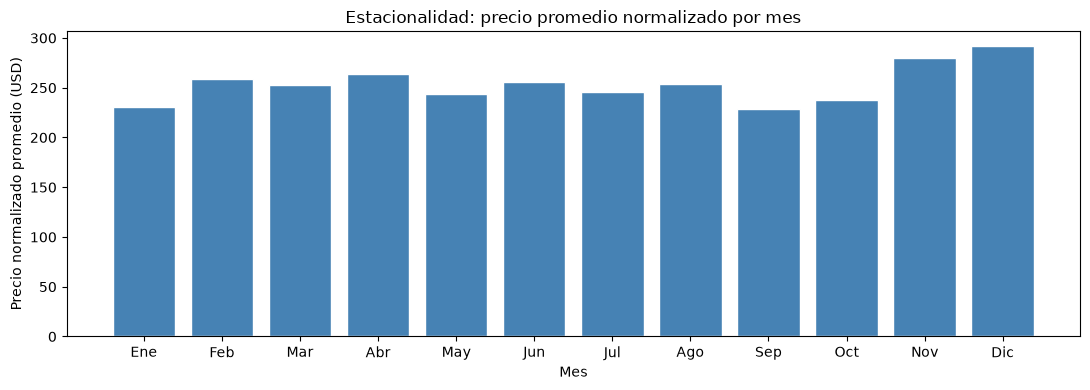

In [190]:
precios_mes = (
    df.groupby('month')['avg_price_average_std']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(precios_mes['month'], precios_mes['avg_price_average_std'],
       color='steelblue', edgecolor='white')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio normalizado promedio (USD)')
ax.set_title('Estacionalidad: precio promedio normalizado por mes')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
plt.tight_layout()
plt.show()

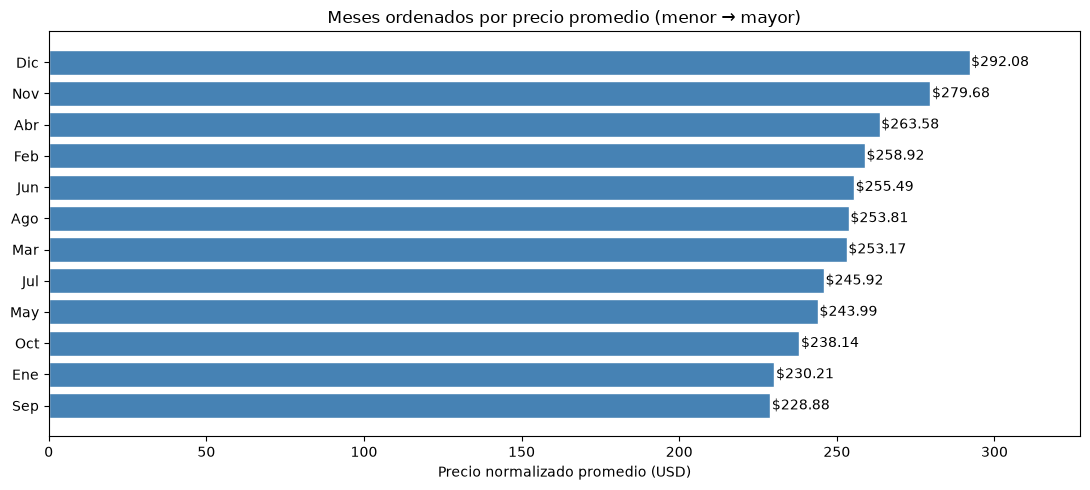

In [191]:
month_names = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
               7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

ordenado = precios_mes.sort_values('avg_price_average_std')
labels = [month_names[m] for m in ordenado['month']]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(labels, ordenado['avg_price_average_std'],
               color='steelblue', edgecolor='white')

for bar, val in zip(bars, ordenado['avg_price_average_std']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}', va='center', fontsize=10)

ax.set_xlabel('Precio normalizado promedio (USD)')
ax.set_title('Meses ordenados por precio promedio (menor → mayor)')
ax.set_xlim(0, ordenado['avg_price_average_std'].max() * 1.12)
plt.tight_layout()
plt.show()

---
## Mapping de destinos

El mapping consolida ~26.000 nombres de ciudades en identificadores únicos de destino canónico.

In [192]:
mapping_df = load_destination_mapping()
print(f'Referencias en el mapping: {len(mapping_df):,}')
print(f'Destinos canónicos únicos: {mapping_df["nearest_destination_id"].nunique():,}')
print()
mapping_df.head()

2026-08-06 23:12:33,528 - INFO - Mapping cargado: 15,988 registros


Referencias en el mapping: 15,988
Destinos canónicos únicos: 2,585



,reference,city,latitude,longitude,nearest_destination_id,nearest_destination_name
0,AD - Andorra La Bella,Andorra La Bella,42.51,1.53,50643,Andorra la Vella
1,AD - Andorra La Vella,Andorra La Vella,42.51,1.53,50643,Andorra la Vella
2,AD - Arinsal,Arinsal,42.58,1.48,50643,Andorra la Vella
3,AD - El Pas de la Casa,El Pas de la Casa,42.54,1.73,21795,Andorra
4,AD - Escaldes-Engordany,Escaldes-Engordany,42.51,1.54,50643,Andorra la Vella


In [193]:
from math import radians, sin, cos, sqrt, atan2, degrees
import numpy as np
import folium

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon_deg = (lon2 - lon1 + 180) % 360 - 180
    dlon = radians(dlon_deg)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

def centroide_geo(lats, lons):
    """Promedio en esfera: maneja antimeridiano correctamente."""
    lats_r = np.radians(lats.astype(float))
    lons_r = np.radians(lons.astype(float))
    x = np.cos(lats_r) * np.cos(lons_r)
    y = np.cos(lats_r) * np.sin(lons_r)
    z = np.sin(lats_r)
    x_m, y_m, z_m = x.mean(), y.mean(), z.mean()
    lon = atan2(y_m, x_m)
    hyp = sqrt(x_m**2 + y_m**2)
    lat = atan2(z_m, hyp)
    return degrees(lat), degrees(lon)

# Centroides de destinos canónicos (usando promedio esférico)
centroides = []
for dest_id, grp in mapping_df.groupby('nearest_destination_id'):
    lat_c, lon_c = centroide_geo(grp['latitude'].values, grp['longitude'].values)
    centroides.append({
        'nearest_destination_id': dest_id,
        'lat_centro': lat_c,
        'lon_centro': lon_c,
        'n_ciudades': len(grp),
        'nombre': grp['nearest_destination_name'].iloc[0]
    })
centroides = pd.DataFrame(centroides)

# Calcular distancia de cada ciudad a su destino canónico
mapping_con_dist = mapping_df.merge(
    centroides[['nearest_destination_id', 'lat_centro', 'lon_centro']],
    on='nearest_destination_id'
)
mapping_con_dist['dist_km'] = mapping_con_dist.apply(
    lambda r: haversine(r['latitude'], r['longitude'], r['lat_centro'], r['lon_centro']), axis=1
)

# Estadísticas globales
print('Distancia a destino canónico (km):')
print(f'  Mediana: {mapping_con_dist["dist_km"].median():.1f} km')
print(f'  P90:     {mapping_con_dist["dist_km"].quantile(0.9):.1f} km')
print(f'  P99:     {mapping_con_dist["dist_km"].quantile(0.99):.1f} km')
print(f'  Máx:     {mapping_con_dist["dist_km"].max():.1f} km')

# Top destinos más dispersos (mayor distancia promedio)
dispersion = mapping_con_dist.groupby('nearest_destination_id').agg(
    nombre=('nearest_destination_name', 'first'),
    n_ciudades=('city', 'count'),
    dist_max=('dist_km', 'max'),
    dist_prom=('dist_km', 'mean')
).sort_values('dist_prom', ascending=False)

print(f'\nTop 10 destinos más dispersos:')
dispersion.head(10)

Distancia a destino canónico (km):
  Mediana: 21.0 km
  P90:     90.4 km
  P99:     210.1 km
  Máx:     1237.2 km

Top 10 destinos más dispersos:


,nombre,n_ciudades,dist_max,dist_prom
nearest_destination_id,,,,
22312,Solomon Islands,3,1133.37,919.96
4359,Homer,13,1237.18,544.88
4495,Nuuk,2,409.15,409.15
5269,Fairbanks,6,493.61,343.14
270,Alaska,9,700.26,287.19
50255,Tumon,14,919.86,255.89
28587,Cascais,2,251.04,251.04
25271,Chisinau,2,245.25,245.25
23636,Northwest Territories,3,359.99,239.94


In [194]:
# Mapa interactivo: TODOS los centroides con filtro por región
import json

# Asignar región a cada destino basado en el prefijo del reference
def get_region(ref):
    if ref.startswith('US'): return 'USA'
    if ref.startswith('MX'): return 'México'
    if ref.startswith(('CA',)): return 'Canadá'
    if ref.startswith(('GB', 'IE', 'FR', 'DE', 'ES', 'IT', 'PT', 'NL', 'BE', 'CH', 'AT', 'SE', 'NO', 'DK', 'FI', 'PL', 'CZ', 'GR', 'TR', 'HU', 'RO', 'BG', 'HR', 'RS', 'BA', 'SK', 'SI', 'LT', 'LV', 'EE', 'IS', 'LU', 'MT', 'CY', 'AL', 'MK', 'ME', 'XK', 'AD', 'MC', 'LI', 'SM', 'VA', 'GI', 'FO', 'GL', 'SJ', 'JE', 'GG', 'IM')): return 'Europa'
    if ref.startswith(('JP', 'CN', 'KR', 'TH', 'VN', 'ID', 'MY', 'PH', 'SG', 'IN', 'LK', 'NP', 'BD', 'MM', 'KH', 'LA', 'TW', 'HK', 'MO')): return 'Asia'
    if ref.startswith(('AU', 'NZ', 'FJ', 'TO', 'WS', 'NC', 'PG', 'VU', 'PF', 'CK', 'NU', 'TK', 'AS', 'GU', 'MP', 'VI', 'PR', 'BM', 'KY', 'TC', 'VG', 'VI', 'MS', 'BL', 'MF', 'GP', 'MQ', 'GF', 'RE', 'YT', 'PM', 'WF', 'PN', 'KI', 'NR', 'TV', 'WS', 'TO', 'FJ', 'MH', 'FM', 'PW')): return 'Oceanía/Pacífico'
    if ref.startswith(('BR', 'AR', 'CL', 'CO', 'PE', 'EC', 'VE', 'BO', 'PY', 'UY', 'CR', 'PA', 'GT', 'HN', 'SV', 'NI', 'CU', 'JM', 'HT', 'DO', 'TT', 'BB', 'BS', 'BZ', 'GY', 'SR', 'GF')): return 'Latam'
    if ref.startswith(('ZA', 'MA', 'EG', 'TN', 'DZ', 'LY', 'NG', 'KE', 'ET', 'GH', 'TZ', 'UG', 'RW', 'BW', 'NA', 'ZM', 'ZW', 'MZ', 'MG', 'MU', 'SC', 'CV', 'ST', 'AO', 'CM', 'SN', 'CI', 'ML', 'BF', 'NE', 'TD', 'CF', 'CD', 'CG', 'GA', 'GQ', 'BI', 'DJ', 'ER', 'SO', 'SS', 'SD', 'SS', 'LR', 'SL', 'GM', 'GN', 'GW', 'TG', 'BJ', 'MR')): return 'África'
    if ref.startswith(('RU', 'UA', 'BY', 'MD', 'GE', 'AM', 'AZ', 'KZ', 'UZ', 'TM', 'KG', 'TJ', 'MN')): return 'Asia Central/East'
    if ref.startswith(('IL', 'JO', 'LB', 'SY', 'IQ', 'IR', 'SA', 'AE', 'QA', 'BH', 'KW', 'OM', 'YE', 'PS')): return 'Medio Oriente'
    return 'Otro'

mapping_con_dist['region'] = mapping_con_dist['reference'].apply(get_region)

# Agregar región a dispersion
region_map = mapping_con_dist.groupby('nearest_destination_id')['region'].agg(lambda x: x.mode()[0])
dispersion['region'] = dispersion.index.map(region_map)
centroides['region'] = centroides['nearest_destination_id'].map(region_map)

regiones = sorted(dispersion['region'].unique())

# Colores por región
region_colors = {
    'USA': '#e6194b', 'México': '#f58231', 'Canadá': '#4363d8',
    'Europa': '#3cb44b', 'Asia': '#911eb4', 'Oceanía/Pacífico': '#42d4f4',
    'Latam': '#f032e6', 'África': '#bfef45', 'Medio Oriente': '#fabed4',
    'Asia Central/East': '#469990', 'Otro': '#dcbeff'
}

m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron')

# Crear FeatureGroups por región (para LayerControl)
fgs = {}
for reg in regiones:
    fgs[reg] = folium.FeatureGroup(name=reg, show=True)

for idx, row in dispersion.iterrows():
    dest_id = idx
    reg = row.get('region', 'Otro')
    color = region_colors.get(reg, '#999999')
    
    lat_c = centroides.loc[centroides['nearest_destination_id'] == dest_id, 'lat_centro'].values
    lon_c = centroides.loc[centroides['nearest_destination_id'] == dest_id, 'lon_centro'].values
    if len(lat_c) == 0:
        continue
    lat_c, lon_c = lat_c[0], lon_c[0]
    
    # Círculo del radio de mapeo (zona)
    folium.Circle(
        location=[lat_c, lon_c],
        radius=row['dist_max'] * 1000,
        color=color, fill=True, fill_opacity=0.08, weight=1,
        popup=f"<b>{row['nombre']}</b><br>Región: {reg}<br>{int(row['n_ciudades'])} ciudades<br>Max: {row['dist_max']:.0f} km<br>Prom: {row['dist_prom']:.0f} km",
        tooltip=row['nombre']
    ).add_to(fgs[reg])
    
    # Centroide
    folium.CircleMarker(
        location=[lat_c, lon_c],
        radius=max(3, min(10, row['n_ciudades'] / 5)),
        color=color, fill=True, fill_opacity=0.8, weight=1,
        tooltip=row['nombre']
    ).add_to(fgs[reg])

# Agregar FeatureGroups al mapa
for fg in fgs.values():
    fg.add_to(m)

# Control de capas
folium.LayerControl(collapsed=False).add_to(m)

# Leyenda HTML
legend_html = '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;padding:10px;border-radius:5px;border:2px solid grey;font-size:12px;">'
legend_html += '<b>Filtrar por región</b><br>(usar LayerControl arriba a la derecha)<br><br>'
for reg in regiones:
    c = region_colors.get(reg, '#999')
    n = dispersion[dispersion['region']==reg]['n_ciudades'].sum()
    legend_html += f'<span style="background:{c};width:12px;height:12px;display:inline-block;border-radius:50%;margin-right:5px;"></span>{reg} ({int(n)})<br>'
legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

print(f'Total centroides: {len(dispersion)}')
for reg in regiones:
    n = len(dispersion[dispersion['region']==reg])
    print(f'  {reg}: {n} destinos')

m

Total centroides: 2585
  Asia: 379 destinos
  Asia Central/East: 17 destinos
  Canadá: 58 destinos
  Europa: 954 destinos
  Latam: 280 destinos
  Medio Oriente: 44 destinos
  México: 82 destinos
  Oceanía/Pacífico: 187 destinos
  Otro: 40 destinos
  USA: 399 destinos
  África: 145 destinos


In [195]:
df = apply_destination_mapping(df, mapping_df)

print('Resultado del mapping:')
print(f'  Destinos únicos finales:         {df["destination_final"].nunique():,}')
sin_mapeo = df['destination_final'].isna().sum()
print(f'  Sin mapeo (fallback a ciudad):   {sin_mapeo:,} registros ({sin_mapeo/len(df):.1%})')
con_mapeo = (~df['destination_final'].isna()).sum()
print(f'  Con mapeo canónico:              {con_mapeo:,} registros ({con_mapeo/len(df):.1%})')

2026-08-06 23:12:40,020 - INFO - Mapping aplicado: 0/438,858 registros (0.0%)
2026-08-06 23:12:40,032 - INFO - Destinos únicos: 1,222


Resultado del mapping:
  Destinos únicos finales:         1,222
  Sin mapeo (fallback a ciudad):   0 registros (0.0%)
  Con mapeo canónico:              438,858 registros (100.0%)


---
## Arrancá tu exploración acá

Usá las variables `df` (con las features ya construidas) para explorar las dimensiones del TP1:
- `avg_price_average_std`: precio normalizado
- `destination_final`: destino canónico
- `month`, `week_in_month`: features temporales
- `count_repeated`: proxy de demanda
- `avg_hotel_count`: proxy de oferta
- `nights`: duración de estadía
- `number_of_adults`, `number_of_rooms`: composición del viaje

In [196]:
# Arrancá acá con tu exploración
